In [1]:
import os
import sys

# Change the notebook's active working directory to the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Ensure the root path is also in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.forecasting.data import ForecastDataLoader

#### load data, insted to querying sql again we are going to reuse our forecasting module

In [3]:
df = ForecastDataLoader.load_daily_sales()

c:\end-to-end-Data-Science-project\AI-demand-intelligence-platform\src\forecasting\data.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [4]:
df.head()

,date,sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0


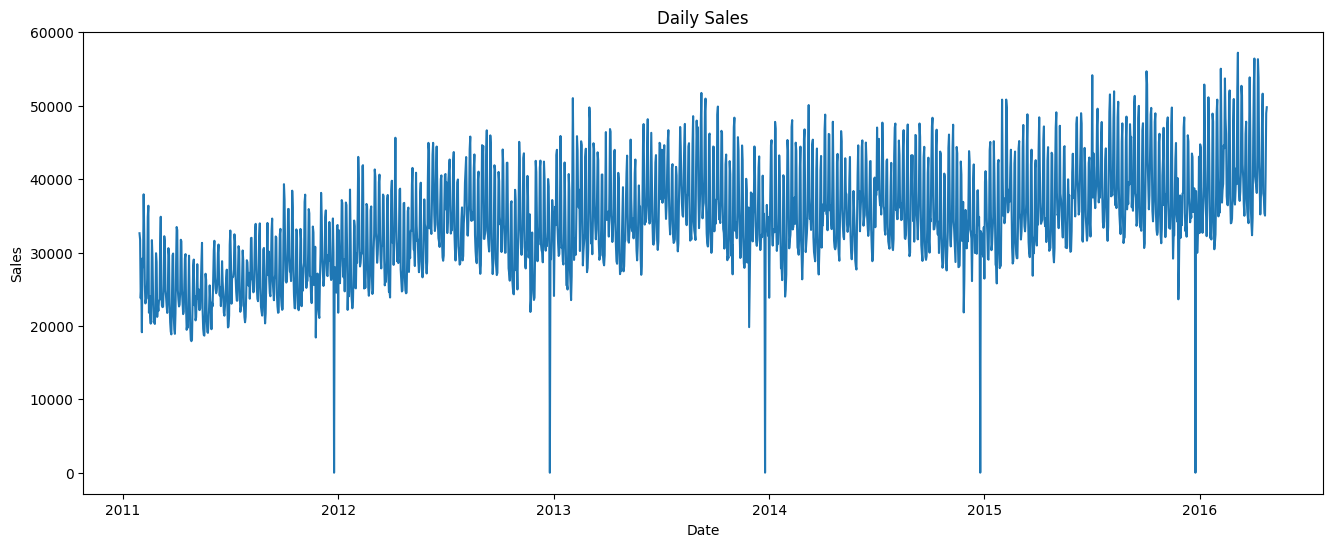

In [5]:
## plot the series

plt.figure(figsize=(16,6))

plt.plot(
    df['date'],
    df['sales']
)

plt.title("Daily Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [6]:
## ADF(Augmented Dickey-Fuller) test
result = adfuller(df['sales'])

In [7]:
print("ADF Statistic :", result[0])

print("p-value :", result[1])

print("Critical Values")

for key, value in result[4].items():

    print(f"{key}: {value:.4f}")

ADF Statistic : -1.565373325331847
p-value : 0.5009604361797743
Critical Values
1%: -3.4338
5%: -2.8631
10%: -2.5676


- p-value is not less than 0.05 therefore series is non-stationary, so we take the following steps.

### 1. First difference

In [8]:
df['sales_diff'] = df['sales'].diff()

In [9]:
## remove the first missing value
df_diff = df.dropna()

### Plot the differenced series

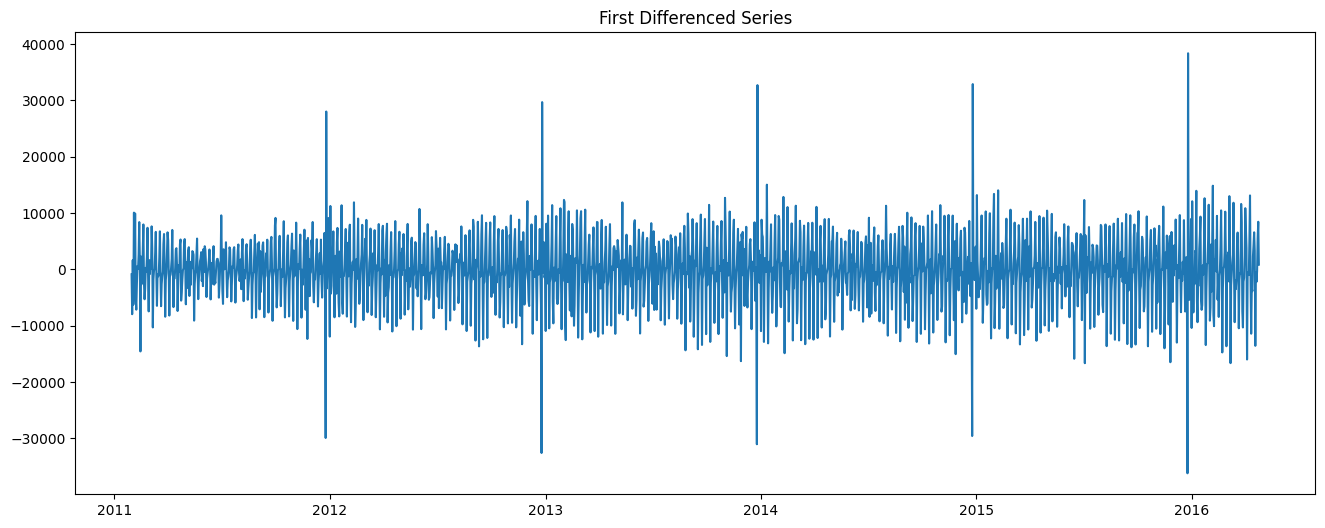

In [10]:
plt.figure(figsize=(16,6))

plt.plot(
    df_diff["date"],
    df_diff["sales_diff"]
)

plt.title("First Differenced Series")

plt.show()

#### Run ADF again

In [14]:
result = adfuller(df_diff['sales_diff'])

print("ADF statistic :", result[0])

print("p-value :", result[1])

ADF statistic : -23.45957882063267
p-value : 0.0


### ACF Plot, which helps us estimate the q parameter

<Figure size 1200x500 with 0 Axes>

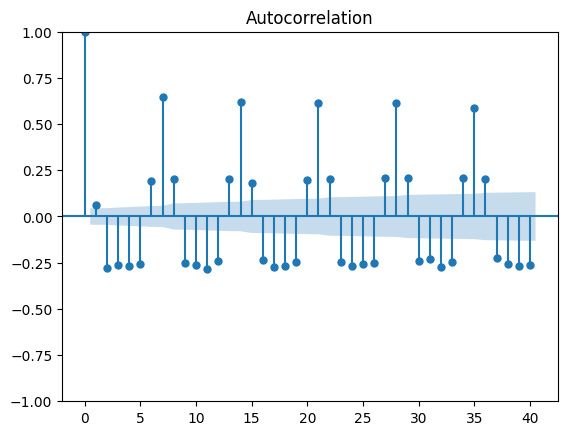

In [15]:
plt.figure(figsize=(12,5))

plot_acf(
    df_diff["sales_diff"],
    lags=40
)

plt.show()

#### PACF plot, helps estimate p parameter

<Figure size 1200x500 with 0 Axes>

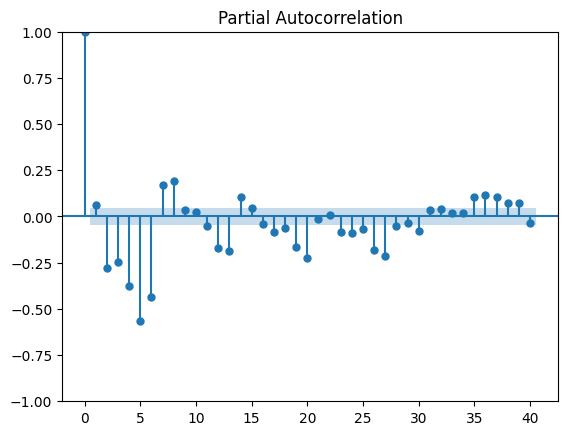

In [16]:
plt.figure(figsize=(12,5))

plot_pacf(
    df_diff["sales_diff"],
    lags=40,
    method="ywm"
)

plt.show()

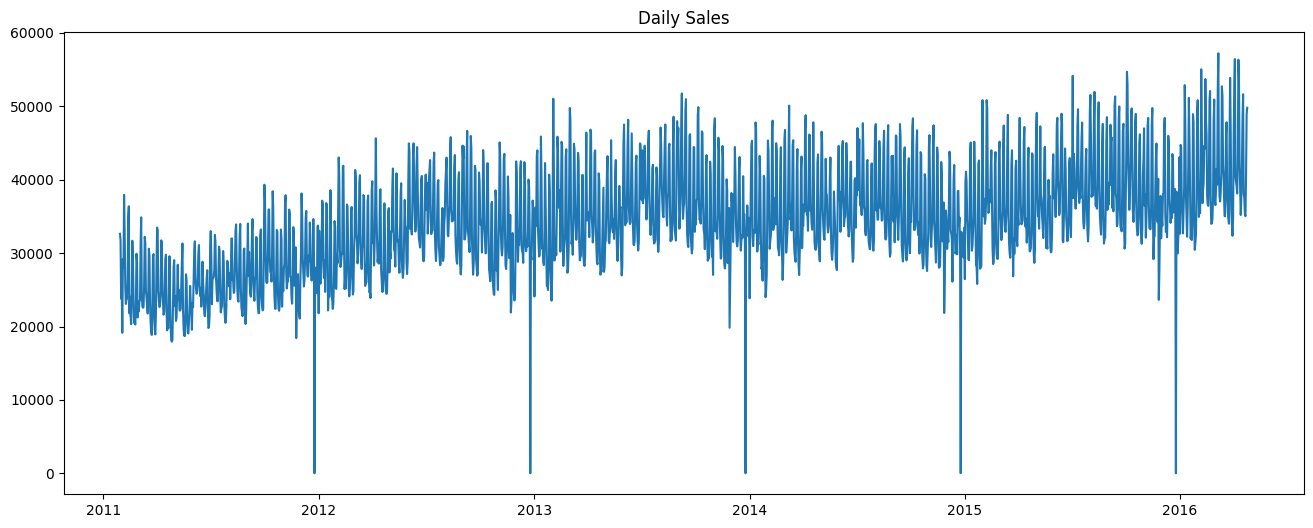

In [17]:
## Save the diagnostic plots:-

plt.figure(figsize=(16,6))
plt.plot(df["date"], df["sales"])
plt.title("Daily Sales")
plt.savefig("artifacts/daily_sales_series.png", dpi=300, bbox_inches="tight")
plt.show()

##### An Augmented Dickey–Fuller test showed the original daily sales series was non-stationary (p = 0.501). After first-order differencing, the series became stationary (p < 0.001), supporting the use of d = 1 in ARIMA-based models. ACF plots revealed strong autocorrelation at multiples of seven days, indicating weekly seasonality and motivating the use of SARIMA with a seasonal period of 7.